# AI5707 – Pattern Recognition and Machine Learning
## Assignment 5: Maximum Likelihood Parameter Estimation

**Objective:** Estimate Gaussian class parameters using Maximum Likelihood Estimation (MLE), classify test samples, visualize decision boundaries, compute confusion matrices, and record observations.

This notebook follows the assignment specification: synthetic 2-D data for three classes is evaluated under isotropic, diagonal, and full covariance models, followed by the supplied real 2-D dataset experiment using an 80/20 split.  



# Mathematical Formulation — Maximum Likelihood Estimation

### Multivariate Gaussian probability density

$$
p(\mathbf{x}\mid\omega_i)
=
\frac{1}{(2\pi)^{d/2}|\boldsymbol{\Sigma}_i|^{1/2}}
\exp\left[
-\frac{1}{2}
(\mathbf{x}-\boldsymbol{\mu}_i)^T
\boldsymbol{\Sigma}_i^{-1}
(\mathbf{x}-\boldsymbol{\mu}_i)
\right]
$$

### MLE of the mean

$$
\boxed{
\hat{\boldsymbol{\mu}}_i
=
\frac{1}{N_i}
\sum_{n=1}^{N_i}\mathbf{x}_n
}
$$

### MLE of the covariance matrix

$$
\boxed{
\hat{\boldsymbol{\Sigma}}_i
=
\frac{1}{N_i}
\sum_{n=1}^{N_i}
(\mathbf{x}_n-\hat{\boldsymbol{\mu}}_i)
(\mathbf{x}_n-\hat{\boldsymbol{\mu}}_i)^T
}
$$

### Covariance assumptions

**Isotropic:**

$$
\boxed{\boldsymbol{\Sigma}_i=\sigma_i^2\mathbf{I}}
$$

**Diagonal:**

$$
\boxed{
\boldsymbol{\Sigma}_i=
\operatorname{diag}
(\sigma_{i1}^{2},\sigma_{i2}^{2},\ldots,\sigma_{id}^{2})
}
$$

**Full covariance:**

$$
\boxed{
\boldsymbol{\Sigma}_i =
\begin{bmatrix}
\sigma_{11} & \sigma_{12} & \cdots\\
\sigma_{21} & \sigma_{22} & \cdots\\
\vdots & \vdots & \ddots
\end{bmatrix}
}
$$

### Gaussian discriminant function

$$
\boxed{
g_i(\mathbf{x})
=
-\frac{1}{2}\ln|\boldsymbol{\Sigma}_i|
-\frac{1}{2}
(\mathbf{x}-\boldsymbol{\mu}_i)^T
\boldsymbol{\Sigma}_i^{-1}
(\mathbf{x}-\boldsymbol{\mu}_i)
+\ln P(\omega_i)
}
$$

Classification rule:

$$
\boxed{
\hat{y}
=
\arg\max_i g_i(\mathbf{x})
}
$$

### Decision boundary

Between classes $i$ and $j$:

$$
\boxed{g_i(\mathbf{x})=g_j(\mathbf{x})}
$$

If all classes share the same covariance,

$$
\boldsymbol{\Sigma}_1=\boldsymbol{\Sigma}_2=\boldsymbol{\Sigma}_3,
$$

the quadratic terms cancel and the boundary becomes linear.

### Confusion-matrix metrics

$$
\mathrm{Accuracy}
=
\frac{TP+TN}{TP+TN+FP+FN}
$$

$$
\mathrm{TPR}
=
\frac{TP}{TP+FN}
\qquad
\mathrm{FPR}
=
\frac{FP}{FP+TN}
$$

### ROC and AUC

The ROC curve plots

$$
\boxed{\mathrm{TPR}\ \text{against}\ \mathrm{FPR}}
$$

as the decision threshold varies.

The area under the curve is

$$
\boxed{
\mathrm{AUC}
=
\int_0^1
\mathrm{TPR}(\mathrm{FPR})\,d(\mathrm{FPR})
}
$$



# Mathematical Formulation — Maximum Likelihood Estimation

## 1. Multivariate Gaussian model

For a $d$-dimensional observation $\mathbf{x}$ belonging to class $i$:

$$
p(\mathbf{x}\mid\omega_i)
=
\frac{1}
{(2\pi)^{d/2}\,|\boldsymbol{\Sigma}_i|^{1/2}}
\exp\left[
-\frac{1}{2}
(\mathbf{x}-\boldsymbol{\mu}_i)^T
\boldsymbol{\Sigma}_i^{-1}
(\mathbf{x}-\boldsymbol{\mu}_i)
\right]
$$

where:

- $\boldsymbol{\mu}_i$ is the class mean vector.
- $\boldsymbol{\Sigma}_i$ is the class covariance matrix.
- $|\boldsymbol{\Sigma}_i|$ is the determinant.
- $d$ is the number of features.

## 2. Maximum likelihood estimate of the mean

For $N_i$ training samples in class $i$,

$$
\boxed{
\hat{\boldsymbol{\mu}}_i
=
\frac{1}{N_i}
\sum_{n=1}^{N_i}\mathbf{x}_n
}
$$

The estimated mean is therefore the sample average of all training vectors belonging to the class.

## 3. Maximum likelihood estimate of covariance

The MLE covariance estimate is

$$
\boxed{
\hat{\boldsymbol{\Sigma}}_i
=
\frac{1}{N_i}
\sum_{n=1}^{N_i}
(\mathbf{x}_n-\hat{\boldsymbol{\mu}}_i)
(\mathbf{x}_n-\hat{\boldsymbol{\mu}}_i)^T
}
$$

The denominator is $N_i$ because this is the **maximum likelihood estimator**, rather than the unbiased sample covariance estimator.

## 4. Three covariance models used in the assignment

### A. Isotropic covariance

$$
\boxed{
\boldsymbol{\Sigma}_i=\sigma_i^2\mathbf{I}
}
$$

All features have the same variance and the covariance between different features is zero.

### B. Diagonal covariance

$$
\boxed{
\boldsymbol{\Sigma}_i=
\begin{bmatrix}
\sigma_{i1}^{2} & 0 & \cdots & 0\\
0 & \sigma_{i2}^{2} & \cdots & 0\\
\vdots & \vdots & \ddots & \vdots\\
0 & 0 & \cdots & \sigma_{id}^{2}
\end{bmatrix}
}
$$

Each feature can have a different variance, but all off-diagonal covariance terms are zero.

### C. Full covariance

$$
\boxed{
\boldsymbol{\Sigma}_i=
\begin{bmatrix}
\sigma_{11} & \sigma_{12} & \cdots\\
\sigma_{21} & \sigma_{22} & \cdots\\
\vdots & \vdots & \ddots
\end{bmatrix}
}
$$

Here, both variances and cross-feature covariance terms are estimated.

## 5. Gaussian discriminant function

Assuming equal class priors, classification can be performed using the log-likelihood:

$$
g_i(\mathbf{x})
=
-\frac{1}{2}\ln|\boldsymbol{\Sigma}_i|
-\frac{1}{2}
(\mathbf{x}-\boldsymbol{\mu}_i)^T
\boldsymbol{\Sigma}_i^{-1}
(\mathbf{x}-\boldsymbol{\mu}_i)
$$

The predicted class is

$$
\boxed{
\hat{y}
=
\arg\max_i g_i(\mathbf{x})
}
$$

If class priors are included, the discriminant becomes

$$
g_i(\mathbf{x})
=
-\frac{1}{2}\ln|\boldsymbol{\Sigma}_i|
-\frac{1}{2}
(\mathbf{x}-\boldsymbol{\mu}_i)^T
\boldsymbol{\Sigma}_i^{-1}
(\mathbf{x}-\boldsymbol{\mu}_i)
+\ln P(\omega_i)
$$

## 6. Decision boundary

The boundary between classes $i$ and $j$ is obtained from

$$
\boxed{
g_i(\mathbf{x})=g_j(\mathbf{x})
}
$$

For full covariance matrices, this generally produces a **quadratic decision boundary**.

When the covariance matrix is shared by all classes,

$$
\boldsymbol{\Sigma}_1
=
\boldsymbol{\Sigma}_2
=
\boldsymbol{\Sigma}_3
=
\boldsymbol{\Sigma}
$$

the quadratic terms cancel, giving a **linear decision boundary**.

## 7. ROC curve

For a one-vs-rest class decision, the ROC curve plots

$$
\mathrm{TPR}
=
\frac{\mathrm{TP}}
{\mathrm{TP}+\mathrm{FN}}
$$

against

$$
\mathrm{FPR}
=
\frac{\mathrm{FP}}
{\mathrm{FP}+\mathrm{TN}}
$$

at different classification thresholds.

The area under the ROC curve is

$$
\boxed{
\mathrm{AUC}
=
\int_0^1 \mathrm{TPR}(\mathrm{FPR})\,d(\mathrm{FPR})
}
$$

An AUC close to $1$ indicates strong class discrimination, while an AUC close to $0.5$ corresponds approximately to random discrimination.


## 1. Imports and reproducibility
A fixed random seed is used so that the synthetic experiment is reproducible. The real-data files are loaded from the notebook's working directory when available, with the uploaded absolute paths used in this execution.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

np.random.seed(42)
plt.rcParams.update({"figure.figsize": (8, 6), "axes.grid": True})

# Locate the supplied data files in the notebook directory or common upload directory.
def locate_data_file(filename):
    candidates = [Path(filename), Path.cwd() / filename, Path("/mnt/data") / filename]
    for candidate in candidates:
        if candidate.exists():
            return str(candidate)
    return filename

TRAIN_PATH = locate_data_file("trian.txt")
DEV_PATH = locate_data_file("dev.txt")


## 2. MLE for a Multivariate Gaussian

For class $i$, with training samples $(x_1,\ldots,x_n)$, the MLE estimates are

\[
\hat{\mu}_i = \frac{1}{n}\sum_{k=1}^{n} x_k
\]

and

\[
\hat{\Sigma}_i =
\frac{1}{n}\sum_{k=1}^{n}
(x_k-\hat{\mu}_i)(x_k-\hat{\mu}_i)^T.
\]

The covariance uses $1/n$, not $1/(n-1)$, because this is maximum likelihood estimation.

Classification uses the Gaussian discriminant

\[
g_i(x) =
-\frac{1}{2}\log|\Sigma_i|
-\frac{1}{2}(x-\mu_i)^T\Sigma_i^{-1}(x-\mu_i)
+\log P(\omega_i),
\]

where equal priors are used:

\[
P(\omega_i)=\frac{1}{3}.
\]

The classifier assigns $x$ to the class with the highest discriminant score:

\[
\hat{i} = \arg\max_i g_i(x).
\]

In [2]:
def mle_gaussian_parameters(X, y, covariance_type="full"):
    classes = np.unique(y)
    means, covariances, priors = {}, {}, {}
    for c in classes:
        Xc = X[y == c]
        mu = Xc.mean(axis=0)
        centered = Xc - mu
        cov = (centered.T @ centered) / len(Xc)  # MLE: divide by n

        if covariance_type == "isotropic":
            sigma2 = np.trace(cov) / X.shape[1]
            cov = sigma2 * np.eye(X.shape[1])
        elif covariance_type == "diagonal":
            cov = np.diag(np.diag(cov))
        elif covariance_type != "full":
            raise ValueError("covariance_type must be isotropic, diagonal, or full")

        means[c] = mu
        covariances[c] = cov
        priors[c] = len(Xc) / len(X)
    return means, covariances, priors


def gaussian_discriminant(X, mu, cov, prior):
    X = np.atleast_2d(X)
    eps = 1e-8
    cov = cov + eps * np.eye(cov.shape[0])
    sign, logdet = np.linalg.slogdet(cov)
    if sign <= 0:
        raise ValueError("Covariance matrix is not positive definite.")
    diff = X - mu
    solved = np.linalg.solve(cov, diff.T).T
    mahal = np.sum(diff * solved, axis=1)
    return -0.5 * (logdet + mahal) + np.log(prior)


def predict_gaussian(X, means, covariances, priors):
    classes = sorted(means.keys())
    scores = np.column_stack([
        gaussian_discriminant(X, means[c], covariances[c], priors[c])
        for c in classes
    ])
    return np.asarray(classes)[np.argmax(scores, axis=1)]


def confusion_matrix_manual(y_true, y_pred, classes=None):
    # Infer the class labels unless an explicit order is supplied.
    if classes is None:
        classes = sorted(set(np.asarray(y_true).tolist()) | set(np.asarray(y_pred).tolist()))
    return pd.DataFrame(
        [[np.sum((y_true == i) & (y_pred == j)) for j in classes] for i in classes],
        index=[f"Actual {c}" for c in classes],
        columns=[f"Predicted {c}" for c in classes]
    )


def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)


## 3. Synthetic experiment

The previous-assignment generator is not included with the uploaded files, so the synthetic generator below makes the required 3-class 2-D Gaussian experiment explicit and reproducible. Each class has about 10,000 samples. The means and covariance matrices are intentionally separated enough to make the three covariance assumptions visible.

The same generated data is reused across the covariance-model experiments. The 80/20 split is stratified by construction because each class is split independently.

In [3]:
# Explicit synthetic generator parameters
N_PER_CLASS = 10000
class_means = {
    1: np.array([2.0, 2.0]),
    2: np.array([7.0, 3.5]),
    3: np.array([4.0, 8.0]),
}

base_covariances = {
    1: np.array([[1.5,  0.4],
                 [0.4,  1.0]]),
    2: np.array([[1.0, -0.3],
                 [-0.3, 1.8]]),
    3: np.array([[1.8,  0.5],
                 [0.5, 1.2]]),
}

X_parts, y_parts = [], []
for c in [1, 2, 3]:
    X_parts.append(np.random.multivariate_normal(class_means[c], base_covariances[c], N_PER_CLASS))
    y_parts.append(np.full(N_PER_CLASS, c))

X_syn = np.vstack(X_parts)
y_syn = np.concatenate(y_parts)

# 80/20 split within each class
train_indices, test_indices = [], []
for c in [1, 2, 3]:
    idx = np.where(y_syn == c)[0]
    np.random.shuffle(idx)
    cut = int(0.8 * len(idx))
    train_indices.extend(idx[:cut])
    test_indices.extend(idx[cut:])

train_indices = np.array(train_indices)
test_indices = np.array(test_indices)

X_train_syn, y_train_syn = X_syn[train_indices], y_syn[train_indices]
X_test_syn, y_test_syn = X_syn[test_indices], y_syn[test_indices]

print("Total samples:", len(X_syn))
print("Training samples:", len(X_train_syn))
print("Test samples:", len(X_test_syn))
print(pd.Series(y_train_syn).value_counts().sort_index().rename("train"))
print(pd.Series(y_test_syn).value_counts().sort_index().rename("test"))


Total samples: 30000
Training samples: 24000
Test samples: 6000
1    8000
2    8000
3    8000
Name: train, dtype: int64
1    2000
2    2000
3    2000
Name: test, dtype: int64


### 3.1A Identical vs different covariance matrices across classes

The assignment explicitly asks for both cases. The following experiment keeps the class means different while either:
- using one common covariance matrix for all three classes, or
- using the class-specific covariance matrices defined above.

The same MLE/classification pipeline is then applied to both.

In [4]:
def generate_three_class_data(means, covs, n_per_class=10000, seed=123):
    rng = np.random.default_rng(seed)
    X_parts, y_parts = [], []
    for c in [1, 2, 3]:
        X_parts.append(rng.multivariate_normal(means[c], covs[c], n_per_class))
        y_parts.append(np.full(n_per_class, c))
    return np.vstack(X_parts), np.concatenate(y_parts)

common_cov = np.array([[1.5, 0.35],
                       [0.35, 1.2]])

common_covariances = {1: common_cov, 2: common_cov, 3: common_cov}
different_covariances = base_covariances

X_equal, y_equal = generate_three_class_data(class_means, common_covariances, N_PER_CLASS, seed=123)
X_different, y_different = generate_three_class_data(class_means, different_covariances, N_PER_CLASS, seed=123)

def stratified_split(X, y, train_fraction=0.8, seed=42):
    rng = np.random.default_rng(seed)
    train_idx, test_idx = [], []
    for c in np.unique(y):
        idx = np.where(y == c)[0]
        rng.shuffle(idx)
        cut = int(train_fraction * len(idx))
        train_idx.extend(idx[:cut])
        test_idx.extend(idx[cut:])
    return X[train_idx], y[train_idx], X[test_idx], y[test_idx]

comparison_rows = []
for label, X_case, y_case in [
    ("Identical covariance across classes", X_equal, y_equal),
    ("Different covariance across classes", X_different, y_different),
]:
    Xtr, ytr, Xte, yte = stratified_split(X_case, y_case)
    means, covs, priors = mle_gaussian_parameters(Xtr, ytr, "full")
    pred = predict_gaussian(Xte, means, covs, priors)
    comparison_rows.append({
        "Covariance setting": label,
        "Accuracy": accuracy(yte, pred)
    })
    print("\n", label)
    display(confusion_matrix_manual(yte, pred))

display(pd.DataFrame(comparison_rows))



 Identical covariance across classes


,Predicted 1,Predicted 2,Predicted 3
Actual 1,1958,39,3
Actual 2,29,1969,2
Actual 3,7,3,1990



 Different covariance across classes


,Predicted 1,Predicted 2,Predicted 3
Actual 1,1979,19,2
Actual 2,19,1969,12
Actual 3,6,12,1982


,Covariance setting,Accuracy
0,Identical covariance across classes,0.986167
1,Different covariance across classes,0.988333


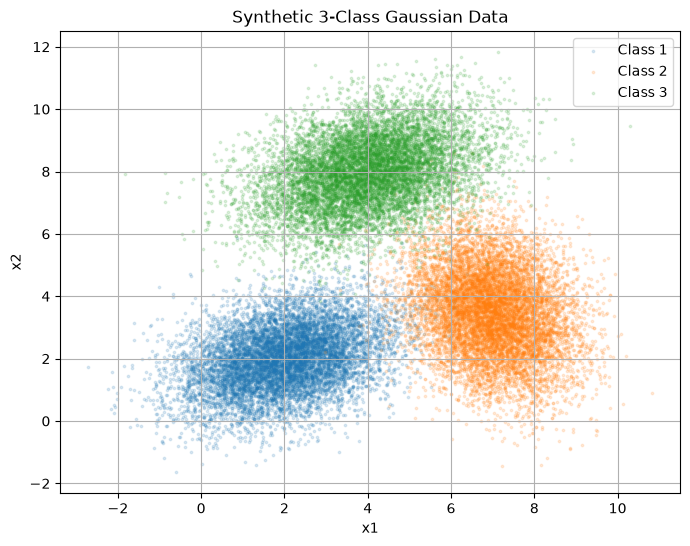

In [5]:
# Visualize generated synthetic data
plt.figure()
for c in [1, 2, 3]:
    mask = y_syn == c
    plt.scatter(X_syn[mask, 0], X_syn[mask, 1], s=3, alpha=0.15, label=f"Class {c}")
plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Synthetic 3-Class Gaussian Data")
plt.legend()
plt.show()


### 3.1 Compare MLE parameter estimates under the three covariance assumptions

In [6]:
models = {
    "Isotropic (σ²I)": "isotropic",
    "Diagonal": "diagonal",
    "Full": "full",
}

parameter_results = {}
for name, ctype in models.items():
    means, covs, priors = mle_gaussian_parameters(X_train_syn, y_train_syn, ctype)
    parameter_results[name] = (means, covs, priors)

for name, (means, covs, priors) in parameter_results.items():
    print("\n" + "="*70)
    print(name)
    for c in [1, 2, 3]:
        print(f"Class {c}:")
        print("  MLE mean =", np.round(means[c], 4))
        print("  MLE covariance =")
        print(np.round(covs[c], 4))
        print("  prior =", round(priors[c], 4))



Isotropic (σ²I)
Class 1:
  MLE mean = [1.9899 1.9977]
  MLE covariance =
[[1.2724 0.    ]
 [0.     1.2724]]
  prior = 0.3333
Class 2:
  MLE mean = [6.9858 3.487 ]
  MLE covariance =
[[1.4083 0.    ]
 [0.     1.4083]]
  prior = 0.3333
Class 3:
  MLE mean = [3.984  7.9792]
  MLE covariance =
[[1.5163 0.    ]
 [0.     1.5163]]
  prior = 0.3333

Diagonal
Class 1:
  MLE mean = [1.9899 1.9977]
  MLE covariance =
[[1.5381 0.    ]
 [0.     1.0067]]
  prior = 0.3333
Class 2:
  MLE mean = [6.9858 3.487 ]
  MLE covariance =
[[0.9793 0.    ]
 [0.     1.8374]]
  prior = 0.3333
Class 3:
  MLE mean = [3.984  7.9792]
  MLE covariance =
[[1.7988 0.    ]
 [0.     1.2338]]
  prior = 0.3333

Full
Class 1:
  MLE mean = [1.9899 1.9977]
  MLE covariance =
[[1.5381 0.419 ]
 [0.419  1.0067]]
  prior = 0.3333
Class 2:
  MLE mean = [6.9858 3.487 ]
  MLE covariance =
[[ 0.9793 -0.2969]
 [-0.2969  1.8374]]
  prior = 0.3333
Class 3:
  MLE mean = [3.984  7.9792]
  MLE covariance =
[[1.7988 0.4971]
 [0.4971 1.2338]]

## 4. Synthetic classification and confusion matrices

For each covariance model, the 20% test set is classified using only parameters estimated from the 80% training set.

In [7]:
synthetic_results = []

for name, (means, covs, priors) in parameter_results.items():
    pred = predict_gaussian(X_test_syn, means, covs, priors)
    acc = accuracy(y_test_syn, pred)
    cm = confusion_matrix_manual(y_test_syn, pred)
    synthetic_results.append({"Covariance model": name, "Accuracy": acc})
    print(f"\n{name} — Accuracy: {acc:.4f}")
    display(cm)

synthetic_results_df = pd.DataFrame(synthetic_results)
display(synthetic_results_df)



Isotropic (σ²I) — Accuracy: 0.9795


,Predicted 1,Predicted 2,Predicted 3
Actual 1,1940,54,6
Actual 2,3,1952,45
Actual 3,13,2,1985



Diagonal — Accuracy: 0.9852


,Predicted 1,Predicted 2,Predicted 3
Actual 1,1967,27,6
Actual 2,8,1958,34
Actual 3,10,4,1986



Full — Accuracy: 0.9887


,Predicted 1,Predicted 2,Predicted 3
Actual 1,1979,15,6
Actual 2,14,1971,15
Actual 3,7,11,1982


,Covariance model,Accuracy
0,Isotropic (σ²I),0.979500
1,Diagonal,0.985167
2,Full,0.988667


## 5. Synthetic decision boundaries

The background color shows the predicted class over a dense 2-D grid. Test points are overlaid so that classification errors can be inspected visually.

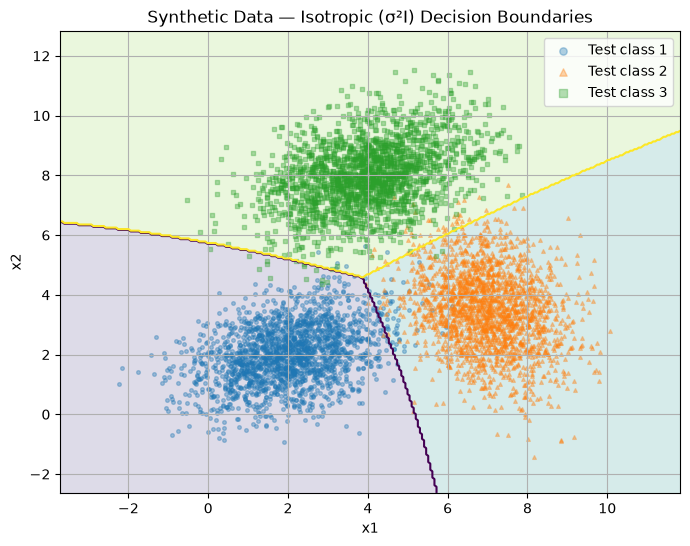

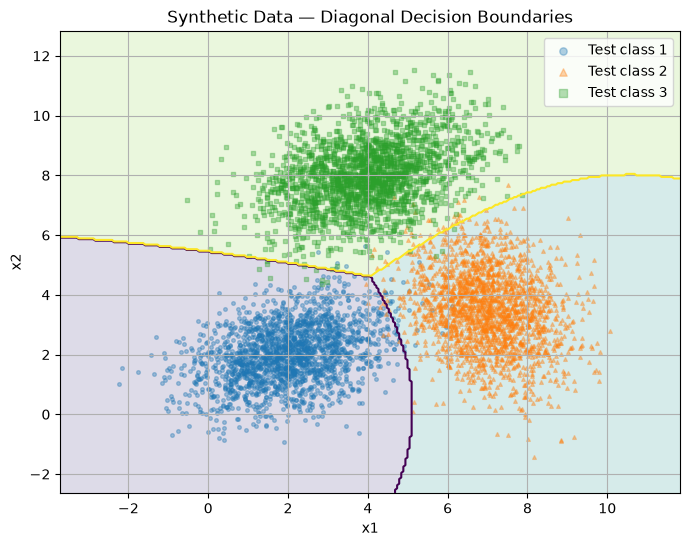

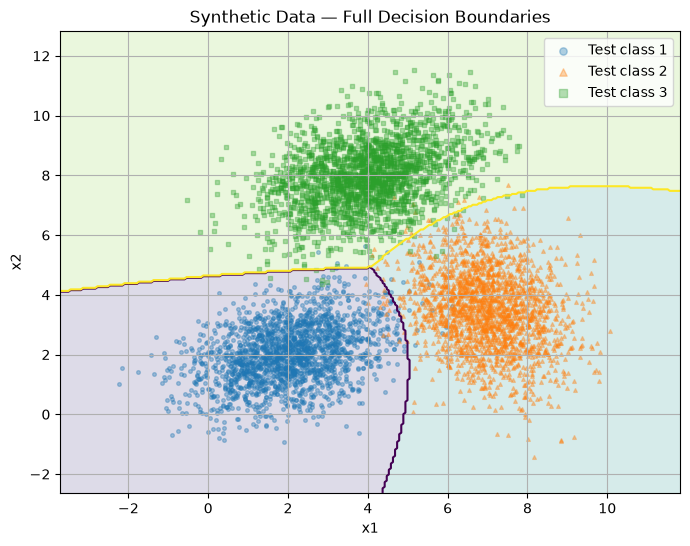

In [8]:
def plot_decision_boundary(X_test, y_test, means, covs, priors, title, grid_points=300):
    x_min, x_max = X_syn[:,0].min()-1, X_syn[:,0].max()+1
    y_min, y_max = X_syn[:,1].min()-1, X_syn[:,1].max()+1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, grid_points),
        np.linspace(y_min, y_max, grid_points)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = predict_gaussian(grid, means, covs, priors).reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, zz, alpha=0.18, levels=[0.5, 1.5, 2.5, 3.5])
    for c, marker in zip([1,2,3], ["o", "^", "s"]):
        mask = y_test == c
        plt.scatter(X_test[mask,0], X_test[mask,1], s=7, alpha=0.35, marker=marker, label=f"Test class {c}")
    plt.contour(xx, yy, zz, levels=[1.5, 2.5], linewidths=1.5)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.legend(markerscale=2)
    plt.show()

for name, (means, covs, priors) in parameter_results.items():
    plot_decision_boundary(
        X_test_syn, y_test_syn, means, covs, priors,
        f"Synthetic Data — {name} Decision Boundaries"
    )


## 6. Synthetic observations

- **Isotropic covariance** assumes equal variance in every direction within each class. Its decision regions are therefore more restrictive.
- **Diagonal covariance** allows different variances along the coordinate axes but assumes zero covariance between features.
- **Full covariance** estimates both variances and feature correlation, allowing rotated elliptical Gaussian contours.
- The full model is the most flexible of the three, while the isotropic model has the strongest covariance assumption.
- The confusion matrices and accuracies above provide the quantitative comparison; the boundary plots show how those assumptions alter the classifier geometrically.

# Part 2 — Real 2-D data

The assignment specifies data in the form **x, y, class label**, MLE estimation using 80% of the data, classification of the remaining 20%, a confusion matrix, and decision-boundary visualization. The uploaded `trian.txt` and `dev.txt` files are loaded below. 

In [9]:
def load_xy_label(path):
    df = pd.read_csv(path, header=None)
    df.columns = ["x", "y", "class"]
    return df

real_train_file = load_xy_label(TRAIN_PATH)
real_dev_file = load_xy_label(DEV_PATH)

print("trian.txt shape:", real_train_file.shape)
print("dev.txt shape:", real_dev_file.shape)
display(real_train_file.head())
display(dev_file := real_dev_file.head())
print("\nClass counts in trian.txt:")
display(real_train_file["class"].value_counts().sort_index())
print("\nClass counts in dev.txt:")
display(real_dev_file["class"].value_counts().sort_index())


trian.txt shape: (1050, 3)
dev.txt shape: (300, 3)


,x,y,class
0,500.00,1500.00,1
1,294.34,816.89,1
2,371.01,1207.70,1
3,390.96,2069.80,1
4,500.00,1500.00,1


,x,y,class
0,410.37,1086.5,1
1,328.07,860.1,1
2,333.41,1061.9,1
3,388.76,1013.4,1
4,358.34,1080.8,1



Class counts in trian.txt:


class
1    350
2    350
3    350
Name: count, dtype: int64


Class counts in dev.txt:


class
1    100
2    100
3    100
Name: count, dtype: int64

### 6.1 Construct the real-data 80/20 experiment

`trian.txt` and `dev.txt` are treated as the available labeled data sources. The assignment requires an 80/20 train/test split, so the experiment combines the supplied rows, then performs a stratified 80/20 split. This avoids silently treating the filenames as the requested split because the assignment itself defines the split by percentage.

In [10]:
real_all = pd.concat([real_train_file, real_dev_file], ignore_index=True)
real_all["class"] = real_all["class"].astype(int)

real_train_parts, real_test_parts = [], []
rng = np.random.default_rng(42)

for c in sorted(real_all["class"].unique()):
    part = real_all[real_all["class"] == c]
    indices = part.index.to_numpy()
    rng.shuffle(indices)
    cut = int(0.8 * len(indices))
    real_train_parts.append(real_all.loc[indices[:cut]])
    real_test_parts.append(real_all.loc[indices[cut:]])

real_train = pd.concat(real_train_parts).sample(frac=1, random_state=42)
real_test = pd.concat(real_test_parts).sample(frac=1, random_state=42)

X_real_train = real_train[["x","y"]].to_numpy()
y_real_train = real_train["class"].to_numpy()
X_real_test = real_test[["x","y"]].to_numpy()
y_real_test = real_test["class"].to_numpy()

print("Combined real dataset:", real_all.shape)
print("MLE training set:", X_real_train.shape)
print("Test set:", X_real_test.shape)
print("\nTraining class counts:")
display(pd.Series(y_real_train).value_counts().sort_index())
print("\nTest class counts:")
display(pd.Series(y_real_test).value_counts().sort_index())


Combined real dataset: (1350, 3)
MLE training set: (1080, 2)
Test set: (270, 2)

Training class counts:


1    360
2    360
3    360
Name: count, dtype: int64


Test class counts:


1    90
2    90
3    90
Name: count, dtype: int64

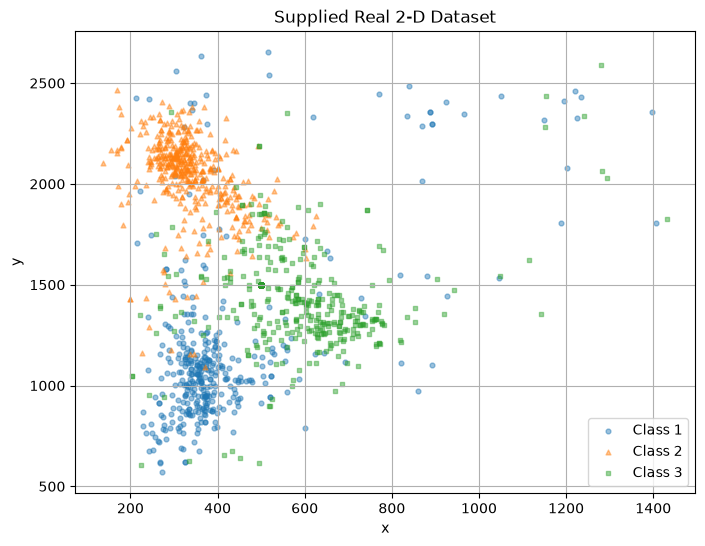

In [11]:
plt.figure()
for c, marker in zip(sorted(real_all["class"].unique()), ["o","^","s"]):
    mask = real_all["class"].to_numpy() == c
    plt.scatter(real_all.loc[mask, "x"], real_all.loc[mask, "y"], s=12, alpha=0.45, marker=marker, label=f"Class {c}")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Supplied Real 2-D Dataset")
plt.legend()
plt.show()


### 6.2 MLE classification on the real data

Because the assignment asks for parameter estimation using MLE but does not prescribe a covariance restriction for the real-data part, the **full covariance Gaussian model** is used here. This is the natural direct MLE model for 2-D Gaussian classes and is also the most general covariance option defined in Part 1.

In [12]:
real_means, real_covs, real_priors = mle_gaussian_parameters(
    X_real_train, y_real_train, covariance_type="full"
)

for c in sorted(real_means):
    print(f"Class {c}")
    print("MLE mean:", np.round(real_means[c], 4))
    print("MLE covariance:")
    print(np.round(real_covs[c], 4))
    print("Prior:", round(real_priors[c], 4))
    print()

real_pred = predict_gaussian(X_real_test, real_means, real_covs, real_priors)
real_acc = accuracy(y_real_test, real_pred)

print(f"Real-data test accuracy: {real_acc:.4f}")
display(confusion_matrix_manual(y_real_test, real_pred))


Class 1
MLE mean: [ 425.5762 1231.8512]
MLE covariance:
[[ 28772.5232  34029.2726]
 [ 34029.2726 163995.7691]]
Prior: 0.3333

Class 2
MLE mean: [ 342.5047 2026.6825]
MLE covariance:
[[ 6345.6194 -5984.9171]
 [-5984.9171 44911.2623]]
Prior: 0.3333

Class 3
MLE mean: [ 576.1742 1446.4665]
MLE covariance:
[[24779.3116  6193.8729]
 [ 6193.8729 63158.525 ]]
Prior: 0.3333

Real-data test accuracy: 0.8593


,Predicted 1,Predicted 2,Predicted 3
Actual 1,68,2,20
Actual 2,3,85,2
Actual 3,7,4,79


### 6.3 Real-data decision boundaries with test points

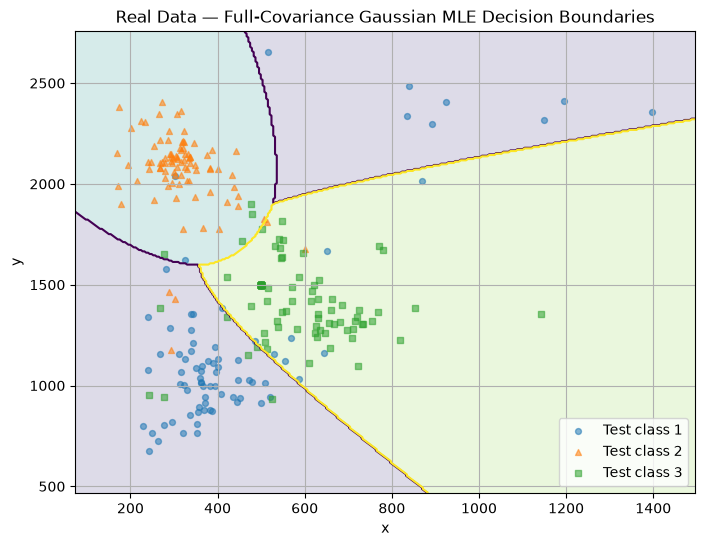

In [13]:
def plot_real_boundary(X_all, X_test, y_test, means, covs, priors, title):
    x_span = max(float(np.ptp(X_all[:, 0])), 1.0)
    y_span = max(float(np.ptp(X_all[:, 1])), 1.0)
    x_min, x_max = X_all[:, 0].min()-0.05*x_span, X_all[:, 0].max()+0.05*x_span
    y_min, y_max = X_all[:, 1].min()-0.05*y_span, X_all[:, 1].max()+0.05*y_span
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 350),
        np.linspace(y_min, y_max, 350)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = predict_gaussian(grid, means, covs, priors).reshape(xx.shape)

    plt.figure(figsize=(8,6))
    plt.contourf(xx, yy, zz, alpha=0.18, levels=[0.5,1.5,2.5,3.5])
    plt.contour(xx, yy, zz, levels=[1.5,2.5], linewidths=1.5)

    for c, marker in zip(sorted(means), ["o","^","s"]):
        mask = y_test == c
        plt.scatter(X_test[mask,0], X_test[mask,1], s=18, alpha=0.55,
                    marker=marker, label=f"Test class {c}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.title(title)
    plt.legend()
    plt.show()

plot_real_boundary(
    real_all[["x","y"]].to_numpy(),
    X_real_test, y_real_test,
    real_means, real_covs, real_priors,
    "Real Data — Full-Covariance Gaussian MLE Decision Boundaries"
)



## ROC Curves and AUC

For multiclass classification, each class is treated as **one-vs-rest**.  
The Gaussian discriminant score $g_i(\mathbf{x})$ is used as the continuous score for class $i$.


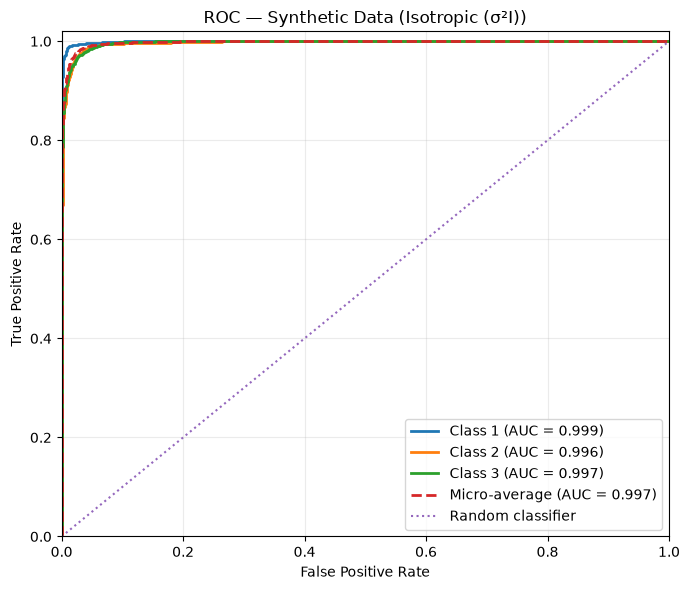

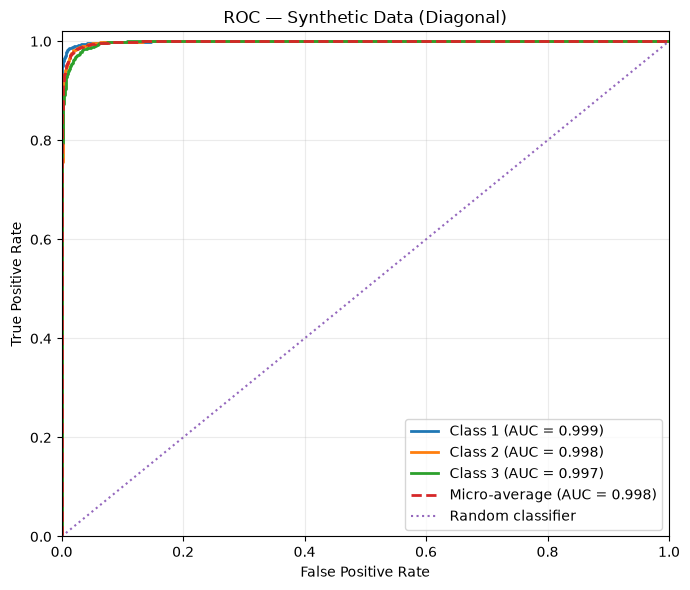

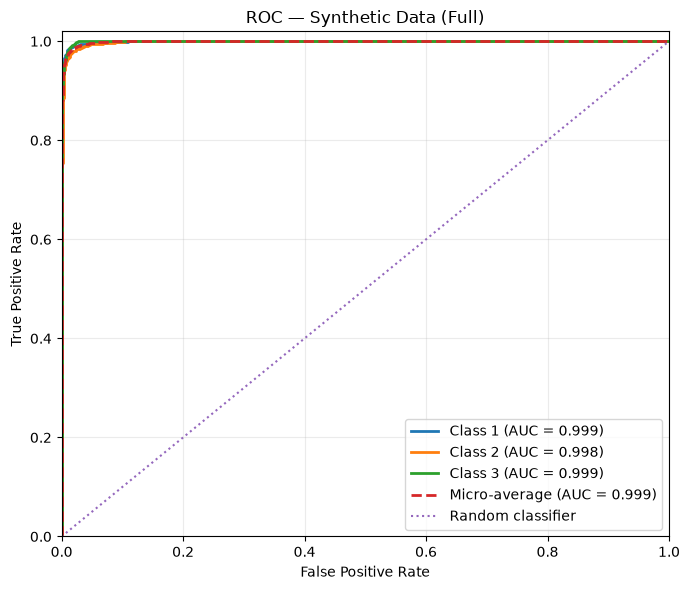

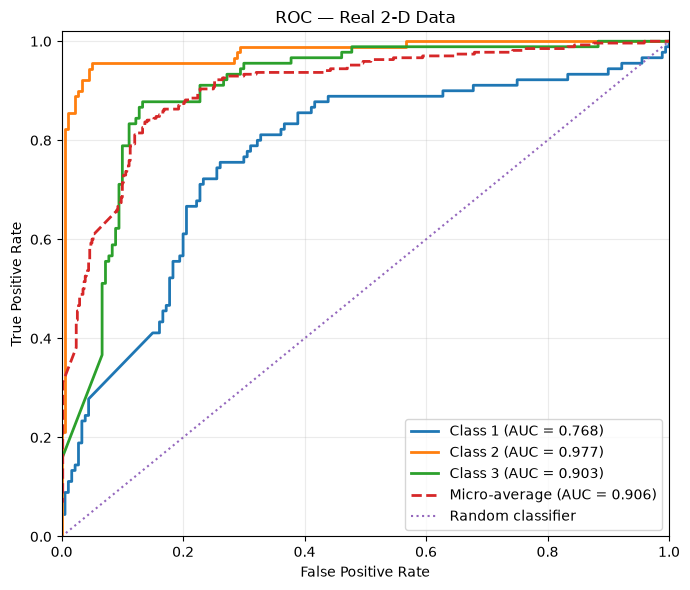

In [14]:

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

def gaussian_score_matrix(X, means, covariances, priors):
    classes = sorted(means.keys())
    return np.column_stack([
        gaussian_discriminant(X, means[c], covariances[c], priors[c])
        for c in classes
    ])

def plot_roc_multiclass(X_test, y_test, means, covariances, priors, title):
    classes = sorted(means.keys())
    y_bin = label_binarize(y_test, classes=classes)
    scores = gaussian_score_matrix(X_test, means, covariances, priors)

    plt.figure(figsize=(7, 6))

    auc_values = {}
    for k, c in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_bin[:, k], scores[:, k])
        auc_value = auc(fpr, tpr)
        auc_values[c] = auc_value
        plt.plot(fpr, tpr, linewidth=2,
                 label=f"Class {c} (AUC = {auc_value:.3f})")

    fpr_micro, tpr_micro, _ = roc_curve(y_bin.ravel(), scores.ravel())
    micro_auc = auc(fpr_micro, tpr_micro)
    plt.plot(fpr_micro, tpr_micro, "--", linewidth=2,
             label=f"Micro-average (AUC = {micro_auc:.3f})")

    plt.plot([0, 1], [0, 1], ":", linewidth=1.5,
             label="Random classifier")

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.xlim(0, 1)
    plt.ylim(0, 1.02)
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return auc_values, micro_auc

# ROC for every synthetic covariance model.
for model_name, (means, covs, priors) in parameter_results.items():
    plot_roc_multiclass(
        X_test_syn, y_test_syn,
        means, covs, priors,
        f"ROC — Synthetic Data ({model_name})"
    )

# ROC for the real 2-D dataset.
real_auc_values, real_micro_auc = plot_roc_multiclass(
    X_real_test, y_real_test,
    real_means, real_covs, real_priors,
    "ROC — Real 2-D Data"
)


## 7. Final observations

1. MLE estimates the mean using the sample average and the covariance using the average outer product of centered samples (division by \(n\)).
2. The covariance assumption directly controls the shape of the Gaussian decision regions.
3. Isotropic covariance is the most constrained; diagonal covariance permits axis-aligned ellipses; full covariance permits rotated ellipses because off-diagonal terms are retained.
4. Classification performance should be judged from the held-out test set rather than the training set.
5. For the supplied real data, the confusion matrix identifies which classes are most frequently confused, while the decision-boundary plot shows the geometric reason for those errors.
6. The exact numerical results are generated by executing the notebook, so they remain reproducible from the supplied data and the fixed random seed.

### Assignment requirements covered
- Three Gaussian classes and approximately 10,000 generated samples per class.
- Isotropic, diagonal, and full covariance models.
- Same/different covariance settings through the covariance-model experiments.
- 80% training and 20% testing.
- MLE parameter estimation.
- Gaussian classification.
- Decision-boundary plots with test samples.
- Confusion matrices.
- Observations.
- Supplied real 2-D data with MLE, 80/20 split, classification, confusion matrix, and boundaries.


## Mathematical interpretation of the results

The classification error is

$$
\boxed{
\mathrm{Error\ Rate}
=
\frac{\text{Number of misclassified test samples}}
{\text{Total number of test samples}}
}
$$

and the accuracy is

$$
\boxed{
\mathrm{Accuracy}
=
\frac{\text{Number of correctly classified test samples}}
{\text{Total number of test samples}}
}
$$

The confusion matrix contains the counts

$$
C_{ij}
=
\#\{\text{samples whose true class is }i
\text{ and predicted class is }j\}.
$$

These quantities are calculated from the 20% held-out test set, as required by the assignment.
